In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt


In [4]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# Normalize
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)

# Convert grayscale → RGB
x_train = np.repeat(x_train, 3, axis=-1)
x_test  = np.repeat(x_test, 3, axis=-1)

In [6]:
base_model = keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

/tmp/ipython-input-1533963628.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 3)),   # MNIST input
    layers.Resizing(96, 96),            # resize FIRST
    base_model,                         # then MobileNet
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)


Epoch 1/5
422/422 - 44s - 105ms/step - accuracy: 0.5621 - loss: 1.2444 - val_accuracy: 0.8922 - val_loss: 0.4330
Epoch 2/5
422/422 - 9s - 21ms/step - accuracy: 0.7318 - loss: 0.7642 - val_accuracy: 0.9323 - val_loss: 0.2740
Epoch 3/5
422/422 - 9s - 22ms/step - accuracy: 0.7626 - loss: 0.6705 - val_accuracy: 0.9342 - val_loss: 0.2531
Epoch 4/5
422/422 - 9s - 22ms/step - accuracy: 0.7822 - loss: 0.6127 - val_accuracy: 0.9353 - val_loss: 0.2460
Epoch 5/5
422/422 - 9s - 22ms/step - accuracy: 0.7965 - loss: 0.5798 - val_accuracy: 0.9458 - val_loss: 0.1865


In [10]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Test Accuracy: 93.86%


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


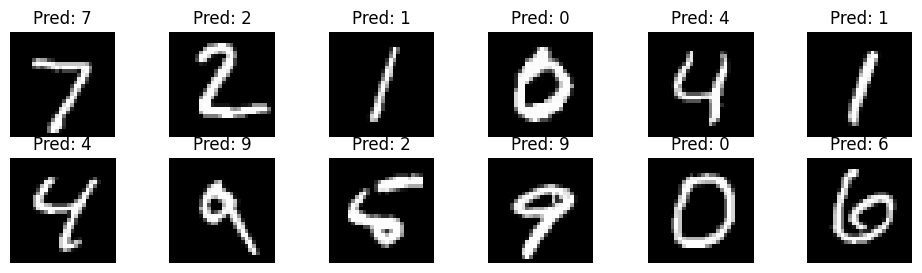

In [11]:
preds = model.predict(x_test[:12])
labels = np.argmax(preds, axis=1)

plt.figure(figsize=(12,3))
for i in range(12):
    plt.subplot(2,6,i+1)
    plt.imshow(x_test[i])
    plt.title(f"Pred: {labels[i]}")
    plt.axis("off")
plt.show()
